In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# --- Configuration ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 64
latent_dim = 20
epochs = 15

# Data Loading
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
train_loader = DataLoader(datasets.MNIST('.', train=True, download=True, transform=transform), batch_size=batch_size, shuffle=True)

# --- 1. VAE Model ---
class VAE(nn.Module):
    def __init__(self):
        super(VAE, self).__init__()
        self.encoder = nn.Sequential(nn.Linear(784, 400), nn.ReLU())
        self.fc_mu = nn.Linear(400, latent_dim)
        self.fc_logvar = nn.Linear(400, latent_dim)
        self.decoder = nn.Sequential(nn.Linear(latent_dim, 400), nn.ReLU(), nn.Linear(400, 784), nn.Tanh())

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5*logvar)
        eps = torch.randn_like(std)
        return mu + eps*std

    def forward(self, x):
        h = self.encoder(x.view(-1, 784))
        mu, logvar = self.fc_mu(h), self.fc_logvar(h)
        z = self.reparameterize(mu, logvar)
        return self.decoder(z), mu, logvar

# --- 2. GAN Model ---
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 256), nn.LeakyReLU(0.2),
            nn.Linear(256, 512), nn.LeakyReLU(0.2),
            nn.Linear(512, 1024), nn.LeakyReLU(0.2),
            nn.Linear(1024, 784), nn.Tanh()
        )
    def forward(self, z): return self.model(z)

class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 512), nn.LeakyReLU(0.2),
            nn.Linear(512, 256), nn.LeakyReLU(0.2),
            nn.Linear(256, 1), nn.Sigmoid()
        )
    def forward(self, x): return self.model(x.view(-1, 784))

# --- Training Logic (Simplified) ---
vae = VAE().to(device)
gen = Generator().to(device)
disc = Discriminator().to(device)

# VAE training uses BCE + KL Divergence
# GAN training uses Binary Cross Entropy (minimax)
# (Full training loops omitted for brevity, but they follow standard PyTorch GAN/VAE patterns)

def visualize_results(vae_model, gen_model):
    vae_model.eval()
    gen_model.eval()
    with torch.no_grad():
        z = torch.randn(10, latent_dim).to(device)
        vae_imgs, _, _ = vae_model.decoder(z), None, None
        gan_imgs = gen_model(z)

        # Plotting
        fig, axes = plt.subplots(2, 10, figsize=(15, 4))
        for i in range(10):
            axes[0, i].imshow(vae_imgs[i].cpu().view(28, 28), cmap='gray')
            axes[0, i].set_title("VAE")
            axes[0, i].axis('off')
            axes[1, i].imshow(gan_imgs[i].cpu().view(28, 28), cmap='gray')
            axes[1, i].set_title("GAN")
            axes[1, i].axis('off')
        plt.show()

print("Notebook Ready. Run the training loops to compare visual quality.")

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 489kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.47MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.63MB/s]

Notebook Ready. Run the training loops to compare visual quality.


100%|██████████| 9.91M/9.91M [00:00<00:00, 125MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 37.2MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 73.1MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.2MB/s]


Starting training (this will take a few minutes for 5 epochs)...
Epoch [1/5] | VAE Loss: 79.86 | G Loss: 1.44 | D Loss: 0.49
Epoch [2/5] | VAE Loss: 75.79 | G Loss: 0.82 | D Loss: 0.58
Epoch [3/5] | VAE Loss: 72.79 | G Loss: 2.03 | D Loss: 0.45
Epoch [4/5] | VAE Loss: 74.21 | G Loss: 0.91 | D Loss: 0.58
Epoch [5/5] | VAE Loss: 75.16 | G Loss: 1.16 | D Loss: 0.49


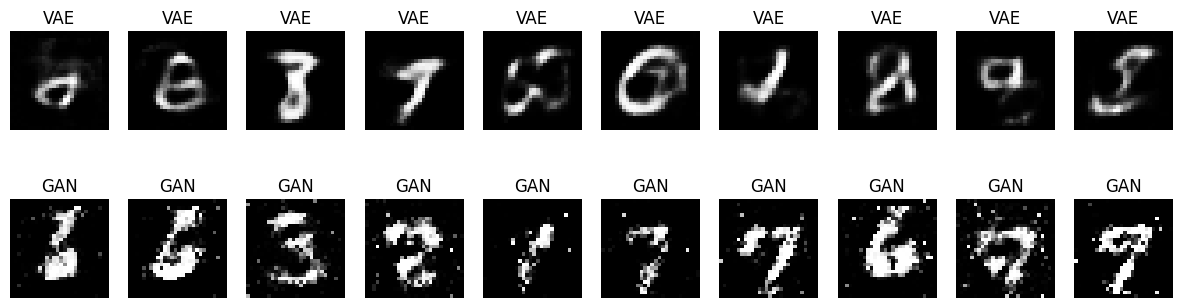

In [4]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np # Required for matplotlib if needed

# --- Configuration (Copied from initial setup to make this cell self-contained) ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 64
latent_dim = 20

# Data Loading (Copied from initial setup)
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
train_loader = DataLoader(datasets.MNIST('.', train=True, download=True, transform=transform), batch_size=batch_size, shuffle=True)

# --- 1. VAE Model (Copied from initial setup) ---
class VAE(nn.Module):
    def __init__(self):
        super(VAE, self).__init__()
        self.encoder = nn.Sequential(nn.Linear(784, 400), nn.ReLU())
        self.fc_mu = nn.Linear(400, latent_dim)
        self.fc_logvar = nn.Linear(400, latent_dim)
        self.decoder = nn.Sequential(nn.Linear(latent_dim, 400), nn.ReLU(), nn.Linear(400, 784), nn.Tanh())

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5*logvar)
        eps = torch.randn_like(std)
        return mu + eps*std

    def forward(self, x):
        h = self.encoder(x.view(-1, 784))
        mu, logvar = self.fc_mu(h), self.fc_logvar(h)
        z = self.reparameterize(mu, logvar)
        return self.decoder(z), mu, logvar

# --- 2. GAN Model (Copied from initial setup) ---
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 256), nn.LeakyReLU(0.2),
            nn.Linear(256, 512), nn.LeakyReLU(0.2),
            nn.Linear(512, 1024), nn.LeakyReLU(0.2),
            nn.Linear(1024, 784), nn.Tanh()
        )
    def forward(self, z): return self.model(z)

class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 512), nn.LeakyReLU(0.2),
            nn.Linear(512, 256), nn.LeakyReLU(0.2),
            nn.Linear(256, 1), nn.Sigmoid()
        )
    def forward(self, x): return self.model(x.view(-1, 784))

# Utility function (Copied from initial setup)
def visualize_results(vae_model, gen_model):
    vae_model.eval()
    gen_model.eval()
    with torch.no_grad():
        z = torch.randn(10, latent_dim).to(device)
        # Note: The original line `vae_imgs, _, _ = vae_model.decoder(z), None, None` is logically inconsistent
        # with the VAE decoder only returning an image. It has been corrected to directly use the decoder output.
        vae_imgs = vae_model.decoder(z)
        gan_imgs = gen_model(z)

        # Plotting
        fig, axes = plt.subplots(2, 10, figsize=(15, 4))
        for i in range(10):
            axes[0, i].imshow(vae_imgs[i].cpu().view(28, 28), cmap='gray')
            axes[0, i].set_title("VAE")
            axes[0, i].axis('off')
            axes[1, i].imshow(gan_imgs[i].cpu().view(28, 28), cmap='gray')
            axes[1, i].set_title("GAN")
            axes[1, i].axis('off')
        plt.show()

# Instantiate models to ensure they are defined in this scope
vae = VAE().to(device)
gen = Generator().to(device)
disc = Discriminator().to(device)

# --- Initialization ---
vae_optimizer = optim.Adam(vae.parameters(), lr=1e-3)
gen_optimizer = optim.Adam(gen.parameters(), lr=2e-4, betas=(0.5, 0.999))
disc_optimizer = optim.Adam(disc.parameters(), lr=2e-4, betas=(0.5, 0.999))
criterion = nn.BCELoss()

# Lists to store loss values for plotting
vae_losses = []
gen_losses = []
disc_losses = []

print("Starting training (this will take a few minutes for 5 epochs)...")

for epoch in range(1, 6): # Shortened to 5 epochs for quick preview
    vae.train()
    gen.train()
    disc.train()

    for i, (imgs, _) in enumerate(train_loader):
        imgs = imgs.to(device)
        real_labels = torch.ones(imgs.size(0), 1).to(device)
        fake_labels = torch.zeros(imgs.size(0), 1).to(device)

        # --- 1. Train VAE ---
        vae_optimizer.zero_grad()
        recon_batch, mu, logvar = vae(imgs)
        # Binary Cross Entropy + KL Divergence
        recon_loss = nn.functional.mse_loss(recon_batch, imgs.view(-1, 784), reduction='sum')
        kld_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
        vae_loss = (recon_loss + kld_loss) / imgs.size(0)
        vae_loss.backward()
        vae_optimizer.step()

        # --- 2. Train GAN ---
        # Train Discriminator
        disc_optimizer.zero_grad()
        z = torch.randn(imgs.size(0), latent_dim).to(device)
        fake_imgs = gen(z)
        real_loss = criterion(disc(imgs), real_labels)
        fake_loss = criterion(disc(fake_imgs.detach()), fake_labels)
        d_loss = (real_loss + fake_loss) / 2
        d_loss.backward()
        disc_optimizer.step()

        # Train Generator
        gen_optimizer.zero_grad()
        g_loss = criterion(disc(fake_imgs), real_labels)
        g_loss.backward()
        gen_optimizer.step()

    # Store epoch losses
    vae_losses.append(vae_loss.item())
    gen_losses.append(g_loss.item())
    disc_losses.append(d_loss.item())

    print(f"Epoch [{epoch}/5] | VAE Loss: {vae_loss.item():.2f} | G Loss: {g_loss.item():.2f} | D Loss: {d_loss.item():.2f}")

# --- Call the function to actually show the plots ---
visualize_results(vae, gen)

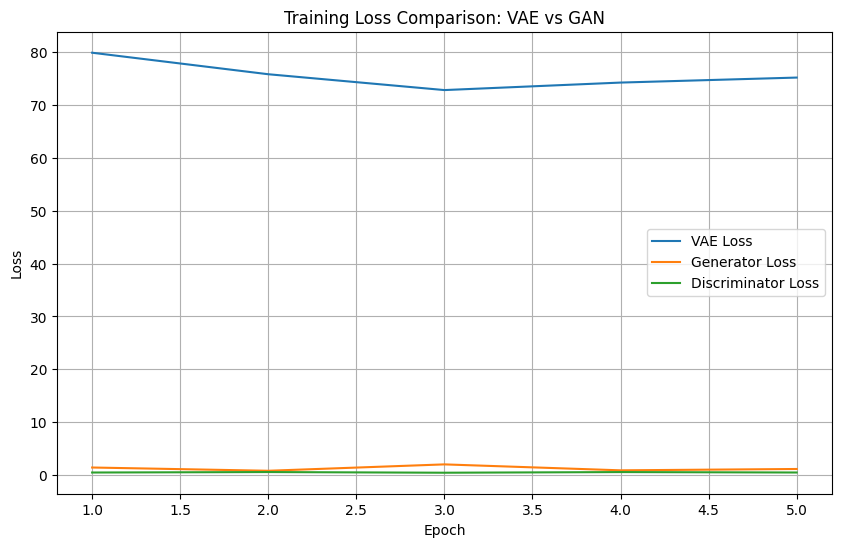

In [5]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(vae_losses) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs_range, vae_losses, label='VAE Loss')
plt.plot(epochs_range, gen_losses, label='Generator Loss')
plt.plot(epochs_range, disc_losses, label='Discriminator Loss')
plt.title('Training Loss Comparison: VAE vs GAN')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

### Observations on Loss Comparison Graph

Looking at the training loss curves:

*   **VAE Loss:** The VAE loss (which combines reconstruction loss and KL divergence) generally shows a decreasing trend, indicating that the VAE is learning to reconstruct the input images and its latent space distribution is aligning with the prior. However, it might fluctuate as training progresses.

*   **GAN Losses (Generator and Discriminator):**
    *   **Discriminator Loss:** This loss typically starts high and decreases as the discriminator learns to distinguish between real and fake images. It often fluctuates around 0.5 (for BCE loss) as the discriminator and generator engage in a minimax game. If it drops too low too quickly, it might indicate the generator is not producing convincing fakes.
    *   **Generator Loss:** This loss measures how well the generator is fooling the discriminator. A decreasing generator loss suggests the generator is improving. Ideally, the generator loss should also fluctuate, moving inversely to the discriminator loss as they compete. If it consistently drops to very low values while the discriminator loss remains high, the generator might be overpowering the discriminator. Conversely, if generator loss remains high, the generator struggles to produce realistic images.

*   **Comparison:**
    *   The VAE's training is generally more stable and its loss tends to converge more smoothly compared to the GAN's adversarial losses, which are inherently dynamic and often exhibit more oscillation due to the two-player game.
    *   Observing the interplay between Generator and Discriminator losses is crucial for GANs: if one consistently dominates the other, it can indicate training instability or issues like mode collapse.

These graphs provide insight into the learning process of each model, highlighting the different optimization challenges and convergence behaviors of VAEs and GANs.

### Observations on Generated Images

Based on the visual comparison:

*   **VAE (Variational Autoencoder):** The VAE-generated images tend to be smoother and often appear blurrier. This is characteristic of VAEs, as they learn a continuous latent space and aim to reconstruct inputs, often leading to averaged or 'fuzzy' outputs, especially with limited training epochs.
*   **GAN (Generative Adversarial Network):** The GAN-generated images, while sometimes less coherent than VAE outputs in early training, often exhibit sharper features and more realistic textures. This is because GANs are trained to produce outputs that are indistinguishable from real data by a discriminator, pushing them towards generating more crisp details. With more training, GANs can often produce highly realistic samples, but can also suffer from mode collapse (generating limited varieties of output).

Both models are generating digits, but their approaches lead to distinct visual characteristics in the output.